## Machine Learning

In [1]:
import pandas as pd

In [2]:
import os 
os.getcwd()

'C:\\Users\\Kaith'

In [3]:
import os


os.chdir(r"C:\Users\Kaith\Desktop\Projects\Emplyoyee_Attrition_Dataset_and_Workforce_Analytics\Datasets")

In [4]:
print(os.getcwd())
print(os.listdir())

C:\Users\Kaith\Desktop\Projects\Emplyoyee_Attrition_Dataset_and_Workforce_Analytics\Datasets
['Cleaned_Employee_Attrition.csv', 'Raw_Employee_Attrition.csv']


In [5]:
df = pd.read_csv("Cleaned_Employee_Attrition.csv")

In [6]:
df.head()

,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [7]:
df.shape

(10000, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             10000 non-null  str    
 1   Age                    10000 non-null  int64  
 2   Department             10000 non-null  str    
 3   JobLevel               10000 non-null  int64  
 4   YearsAtCompany         10000 non-null  int64  
 5   MonthlyIncome          10000 non-null  int64  
 6   JobSatisfaction        10000 non-null  int64  
 7   WorkLifeBalance        10000 non-null  int64  
 8   OverTime               10000 non-null  str    
 9   DistanceFromHome       10000 non-null  float64
 10  PromotionLast5Years    10000 non-null  str    
 11  PerformanceRating      10000 non-null  int64  
 12  TrainingHoursLastYear  10000 non-null  int64  
 13  Attrition              10000 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 1.1 MB


In [9]:
df['Attrition'].value_counts()

Attrition
No     9097
Yes     903
Name: count, dtype: int64

In [10]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [11]:
print(x.shape)
print(y.shape)

(10000, 13)
(10000,)


In [12]:
y = y.map({'Yes': 1, 'No': 0})

In [13]:
y.value_counts()

Attrition
0    9097
1     903
Name: count, dtype: int64

In [14]:
x.select_dtypes(include='object').columns

C:\Users\Kaith\AppData\Local\Temp\ipykernel_12352\3128748426.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x.select_dtypes(include='object').columns


Index(['EmployeeID', 'Department', 'OverTime', 'PromotionLast5Years'], dtype='str')

In [15]:
x = pd.get_dummies(x, drop_first=True)

In [16]:
df["Attrition"].value_counts()

Attrition
No     9097
Yes     903
Name: count, dtype: int64

In [17]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X shape:", X.shape)
print("y.shape:", y.shape)

X shape: (10000, 13)
y.shape: (10000,)


In [18]:
X.dtypes

EmployeeID                   str
Age                        int64
Department                   str
JobLevel                   int64
YearsAtCompany             int64
MonthlyIncome              int64
JobSatisfaction            int64
WorkLifeBalance            int64
OverTime                     str
DistanceFromHome         float64
PromotionLast5Years          str
PerformanceRating          int64
TrainingHoursLastYear      int64
dtype: object

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (8000, 13)
X_test shape: (2000, 13)
y_train shape: (8000,)
y_test shape: (2000,)


In [20]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (10000, 13)
Encoded X shape: (10000, 10016)


In [21]:
y_encoded = y.map({"No": 0, "Yes": 1})

print(y_encoded.value_counts())

Attrition
0    9097
1     903
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split (X_encoded, y_encoded, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 10016)
X_test shape: (2000, 10016)
y_train shape: (8000,)
y_test shape: (2000,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 10016)
X_test_scaled shape: (2000, 10016)


In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [25]:
y_pred = model.predict(X_test_scaled)

print("Predictions created successfully!")
print("Number of predictions:", len(y_pred))


Predictions created successfully!
Number of predictions: 2000


In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.9065
Model Accuracy (%): 90.65 %


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1813
           1       0.00      0.00      0.00       187

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



C:\Users\Kaith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kaith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kaith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

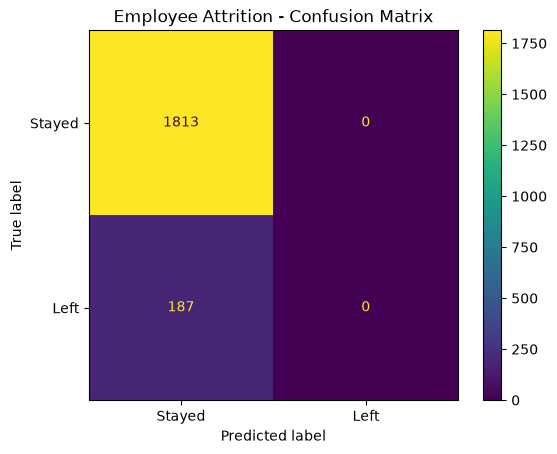

In [28]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay 

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Left"]).plot()

plt.title("Employee Attrition - Confusion Matrix")
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42)

balanced_model.fit(X_train_scaled, y_train)

print("Balanced model training completed successfully!")

Balanced model training completed successfully!


In [30]:
y_pred_balanced = balanced_model.predict(X_test_scaled)

print("Balanced model predictions created successfully!")
print("Number of predictions:", len(y_pred_balanced))

Balanced model predictions created successfully!
Number of predictions: 2000


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1813
           1       0.00      0.00      0.00       187

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



C:\Users\Kaith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kaith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kaith\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [32]:
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Balanced Model Confusion Matrix:")
print(cm_balanced)

Balanced Model Confusion Matrix:
[[1813    0]
 [ 187    0]]


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier (n_estimators=100, random_state=42, class_weight="balanced")

rf_model.fit(X_train, y_train)

print("Random Forest model training completed successfully!")

Random Forest model training completed successfully!


In [34]:
print("Random Forest model exists:", rf_model)

Random Forest model exists: RandomForestClassifier(class_weight='balanced', random_state=42)


In [35]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions created successfully!")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions created successfully!
Number of predictions: 2000


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1813
           1       0.00      0.00      0.00       187

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



In [37]:

print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
Attrition
0    7284
1     716
Name: count, dtype: int64

Testing target distribution:
Attrition
0    1813
1     187
Name: count, dtype: int64


In [38]:
print("Number of test row:", len(y_test))
print("\nExact testing distribution:")
print(y_test.value_counts().sort_index()) 

Number of test row: 2000

Exact testing distribution:
Attrition
0    1813
1     187
Name: count, dtype: int64


In [40]:
print("Exact training distribution:")
print(y_train.value_counts().sort_index()) 

Exact training distribution:
Attrition
0    7284
1     716
Name: count, dtype: int64


In [41]:
print("Random Forest prediction distribution:")
print(pd.Series(y_pred_rf).value_counts().sort_index())

Random Forest prediction distribution:
0    1998
1       2
Name: count, dtype: int64


In [42]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:")
print(cm_rf) 

Random Forest Confusion Matrix:
[[1811    2]
 [ 187    0]]


In [43]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("First 10 attrition probabilities:")
print(y_prob_rf[:10])

First 10 attrition probabilities:
[0.25 0.06 0.36 0.12 0.12 0.19 0.16 0.15 0.19 0.17]


In [44]:
threshold = 0.30

In [45]:
y_pred_threshold = (y_prob_rf >= threshold).astype(int)

In [46]:
print("Stayed:", (y_pred_threshold == 0).sum())
print("Left:", (y_pred_threshold == 1).sum())

Stayed: 1856
Left: 144


In [47]:
print("Prediction distribution at threshold 0.30:")

Prediction distribution at threshold 0.30:


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1813
           1       0.18      0.14      0.16       187

    accuracy                           0.86      2000
   macro avg       0.55      0.54      0.54      2000
weighted avg       0.84      0.86      0.85      2000



In [49]:
cm_threshold = confusion_matrix(y_test, y_pred_threshold)

print("Confusion Matrix at 0.30 Threshold:")
print(cm_threshold)

Confusion Matrix at 0.30 Threshold:
[[1695  118]
 [ 161   26]]


In [50]:
from sklearn.metrics import recall_score

logistic_recall = recall_score(y_test, y_pred)
balanced_recall = recall_score(y_test, y_pred_balanced)
rf_recall = recall_score(y_test, y_pred_rf)
threshold_recall = recall_score(y_test, y_pred_threshold)

print("Logistic Regression Recall:", round(logistic_recall * 100, 2), "%")
print("Balanced Logistic Regression Recall:", round(balanced_recall * 100, 2), "%")
print("Random Forest Recall:", round(rf_recall * 100, 2), "%")
print("Randpm Forest (0.30 threshold) Recall:", round(threshold_recall * 100, 2), "%")

Logistic Regression Recall: 0.0 %
Balanced Logistic Regression Recall: 0.0 %
Random Forest Recall: 0.0 %
Randpm Forest (0.30 threshold) Recall: 13.9 %


In [51]:
from sklearn.metrics import accuracy_score

threshold_accuracy = accuracy_score(y_test, y_pred_threshold)

print("Random Forest (0.30 threshold) Accuracy:", round(threshold_accuracy * 100, 2), "%")     

Random Forest (0.30 threshold) Accuracy: 86.05 %


##  Machine learning

Models were developed to predict employee attrition using the available workforce and employee-related features. The data was prepared for modeling, categorical variables were encoded, and the dataset was divided into training and testing sets. Logistic Regression and Random Forest models were trained and evaluated using appropriate classification metrics, including accuracy, precision, recall, and F1-score. 